In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import gdelt
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...


here


/home/luiyusen/projects/bptf_new


20

In [2]:
def process_date(date):
    """
    Queries the GDELT database and returns all events with a complete token (i.e. source, target country, action and time) by day.
    GDELT 2 only supports 2015 02 18 and onwards.
    Args:
        date: string. YYYY MM DD
    Returns:
        pandas dataframe with source, target country codes, action and day
    """
    try:
        ver = 1 if int(date[:4]) <= 2016 else 2
        gd = gdelt.gdelt(version=ver)
        results = gd.Search([date],table='events',coverage=True)
        results = results[['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions']]
        results.loc[:, 'EventBaseCode'] = results['EventBaseCode'].str[:2]
        results = results.dropna()
        # results = results.groupby(['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE'])
        # results = results.sum().reset_index()
        results = results[results['EventBaseCode'].str.isnumeric()]

        # print(f"Processed: {date} - {len(results)} rows")
        return results
    except Exception as e:
        print(f'Failed to process {date}: {e}')
        return pd.DataFrame(columns=['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions'])

In [3]:
filepath = 'gdelt1.csv'
if os.path.exists(filepath):
    gdelt1 = pd.read_csv(filepath)
    print(f'{filepath} exists')
else:
    "At present the GDELT 2.0 data streams only stretch back to late morning February 19, 2015"
    "From the gdelt documentation"
    print('Downloading GDELT1')
    gdelt1 = [process_date(str(year)) for year in range(2000, 2016)]
    gdelt1 = pd.concat(gdelt1)
    gdelt1 = gdelt1[gdelt1['SQLDATE'] <= 20150218]
    gdelt1.to_csv(filepath, index=False)

print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

gdelt1.csv exists


Earliest date is 2000-01-01 00:00:00


Latest date is 2014-04-10 00:00:00


In [ ]:
gdelt_filepaths = [os.path.join('GDELT', f) for f in os.listdir('GDELT')]

gdelt1_old = [pd.read_csv(gdelt_filepath) for gdelt_filepath in gdelt_filepaths]

gdelt1_old = pd.concat(gdelt1_old)

# combine the data
# we stack the data since the downloaded GDELT data is from before 2015 and the bigquery one is post-2015
# data = data[data['Database'] != 'GDELT']
gdelt1_old['Database'] = 'GDELT'
print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

gdelt1_old = gdelt1_old[gdelt1_old['SQLDATE'] <= 20150218]
print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

In [ ]:
lengths = gdelt1_old['SQLDATE'].astype(str).apply(len).unique()
# Convert to string (if not already done)
gdelt1_old['SQLDATE'] = gdelt1_old['SQLDATE'].astype(str)

# Create a boolean mask for rows that match the 8-digit pattern
mask = gdelt1_old['SQLDATE'].str.match(r'^\d{8}$')
invalid_dates = gdelt1_old.loc[~mask, 'SQLDATE']
print("Invalid SQLDATE entries:\n", invalid_dates)

gdelt1_old['SQLDATE'] = pd.to_datetime(gdelt1_old['SQLDATE'], format='%Y%m%d', errors='coerce')

# Check how many values could not be parsed
invalid_count = gdelt1_old['SQLDATE'].isna().sum()
print(f"Number of unparsed dates: {invalid_count}")

gdelt1_old['month'] = gdelt1_old['SQLDATE'].dt.month
month_counts = gdelt1_old['month'].value_counts().sort_index()

month_counts.plot(kind='bar')
plt.show()

13392553
  Actor1CountryCode Actor2CountryCode  EventBaseCode    SQLDATE  NumMentions  \
0               AFG               AFG              2 2000-01-01            9   
1               AFG               AFG              8 2000-01-01            9   
2               AFG               ARE              3 2000-01-01            2   
3               AFG               IND              4 2000-01-01            7   
4               AFG               IND              4 2000-01-01            9   

   month  
0      1  
1      1  
2      1  
3      1  
4      1  


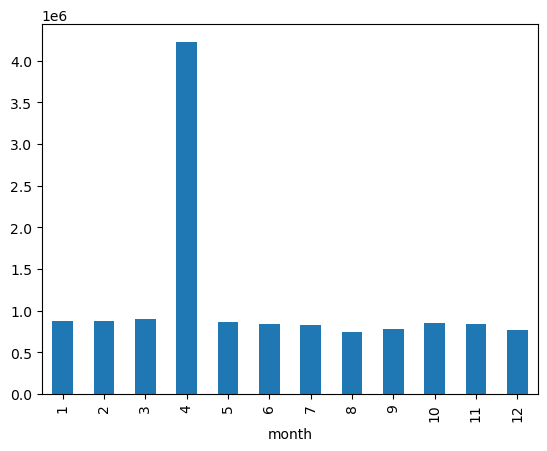

In [6]:
gdelt1['SQLDATE'] = pd.to_datetime(gdelt1['SQLDATE'].astype(str), format='%Y%m%d')
gdelt1 = gdelt1.dropna()
gdelt1['month'] = gdelt1['SQLDATE'].dt.month
month_counts = gdelt1['month'].value_counts().sort_index()
print(len(gdelt1))
month_counts.plot(kind='bar')
print(gdelt1.head())

In [7]:
folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
data = [pd.read_csv(data_filepath + filepath) for filepath in files]
data = pd.concat(data)
# data = data.sort_values(by='Num_Events', ascending=False)
years = [str(2000 + x) for x in range(0, 25)]
data = data[data['formatteddate'].str.startswith(tuple(years))]

   Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
10                 CUB                 NaN           1    2000-06-09   
11                 AZE                 NaN           1    2003-05-05   
12                 ESP                 NaN           1    2004-04-26   
13                 THA                 NaN           1    2005-03-29   
14                 RUS                 NaN           1    2015-11-03   

    Num_Events Database  
10           1  TERRIER  
11           1  TERRIER  
12           1  TERRIER  
13           1  TERRIER  
14           1  TERRIER  


<Axes: xlabel='month'>

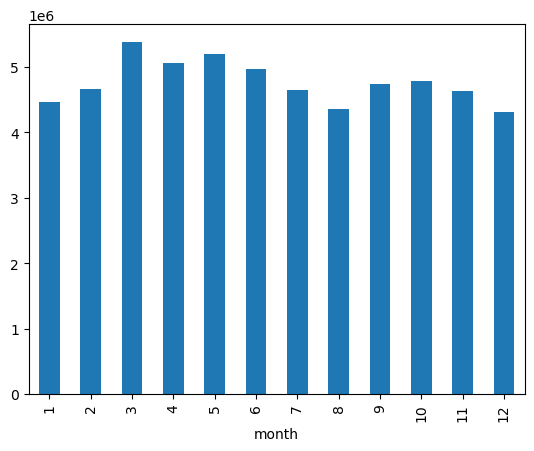

In [8]:
print(data.head())
data['formatteddate'] = pd.to_datetime(data['formatteddate'], format='%Y-%m-%d')
data = data.dropna()
data['month'] = data['formatteddate'].dt.month
month_counts = data['month'].value_counts().sort_index()
month_counts.plot(kind='bar')

In [9]:
gdelt1 = gdelt1.rename(
    columns={
        'Actor1CountryCode' : 'Source_Country_Code',
        'Actor2CountryCode' : 'Target_Country_Code',
        'EventBaseCode' : 'CAMEO_Code',
        'SQLDATE' : 'formatteddate',
        'NumMentions' : 'Num_Events'
    }
)
gdelt1['formatteddate'] = gdelt1['formatteddate'].dt.strftime('%Y-%m-%d')
gdelt1['Database'] = 'GDELT'
gdelt1 = gdelt1.dropna()
new_order = ['Source_Country_Code', 'Target_Country_Code', 'CAMEO_Code',
             'formatteddate', 'Num_Events', 'Database', 'month']
gdelt1 = gdelt1[new_order]
print(gdelt1.dtypes)

Source_Country_Code    object
Target_Country_Code    object
CAMEO_Code              int64
formatteddate          object
Num_Events              int64
Database               object
month                   int32
dtype: object


In [10]:
print(gdelt1.head())
print(data.head())

  Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
0                 AFG                 AFG           2    2000-01-01   
1                 AFG                 AFG           8    2000-01-01   
2                 AFG                 ARE           3    2000-01-01   
3                 AFG                 IND           4    2000-01-01   
4                 AFG                 IND           4    2000-01-01   

   Num_Events Database  month  
0           9    GDELT      1  
1           9    GDELT      1  
2           2    GDELT      1  
3           7    GDELT      1  
4           9    GDELT      1  
      Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
25358                 PAN                 ABW           1    2015-09-27   
25359                 BRB                 ABW           2    2019-10-27   
25360                 ESP                 ABW           2    2017-11-13   
25361                 USA                 ABW           2    2017-12-08   
25362 

In [11]:
combined_data = pd.concat([data, gdelt1])

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fa576a88d50>>
Traceback (most recent call last):
  File "/home/luiyusen/.conda/envs/bptf/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [ ]:
# Ensure 'formatteddate' is in datetime format and extract the year
data['formatteddate'] = pd.to_datetime(data['formatteddate'])
data['year'] = data['formatteddate'].dt.year

# --------------------------------------------
# Step 1: Compute duplicate counts per date, by year and Database
# --------------------------------------------
# Group by year and Database, then count occurrences of each 'formatteddate'
date_counts = data.groupby(['year', 'Database'])['formatteddate'].value_counts()

# For each date that appears more than once, the duplicate count is count - 1
duplicates_per_date = date_counts - 1

# Keep only dates that have duplicates (i.e. count > 0)
duplicates_per_date = duplicates_per_date[duplicates_per_date > 0]

# Sum the duplicate counts for each (year, Database) combination
duplicates_count = duplicates_per_date.groupby(level=[0, 1]).sum()

# --------------------------------------------
# Step 2: Compute total number of rows per (year, Database)
# --------------------------------------------
total_counts = data.groupby(['year', 'Database']).size()

# --------------------------------------------
# Step 3: Combine the totals and duplicates into a summary DataFrame
# --------------------------------------------
result = pd.DataFrame({
    'total_rows': total_counts,
    'duplicate_count': duplicates_count
})

# In case some groups have no duplicates, fill missing duplicate counts with 0
result['duplicate_count'] = result['duplicate_count'].fillna(0)

# Calculate the duplicate ratio (duplicate_count/total_rows)
result['duplicate_ratio'] = result['duplicate_count'] / result['total_rows']

print(result)